### 0. Banco de dados

In [57]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset from UCI Machine Learning Repository
energy_efficiency = fetch_ucirepo(id=242) 
  
# data (as pandas dataframes) 
X = energy_efficiency.data.features 
y = energy_efficiency.data.targets 

X = X.copy()

### 1. Seleção de Features e Preparação dos dados

#### 1.1 Seleção de Features

A seleção de features seguirá os critérios estabelecidos na seção 1.3 — Análise de Dispersão, apresentada na análise exploratória. Para relembrar, as variáveis Orientation (X6) e Glazing Area Distribution (X8) foram descartadas por não apresentarem relação significativa com as variáveis-resposta. A variável Surface Area (X2) também foi excluída por apresentar uma relação de proporcionalidade inversa perfeita com Relative Compactness (X1), evidenciando colinearidade.

Além disso, conforme justificado anteriormente, foram definidas novas categorias para as variáveis Relative Compactness (X1), Roof Area (X4) e Overall Height (X5), a fim de representar melhor os padrões identificados na análise de dispersão.

In [58]:
# Transformando os preditores X1, X4 e X5 em variáveis booleanas
X.loc[:, 'X1_bool'] = X['X1'] < 0.76
X.loc[:, 'X4_bool'] = X['X4'] < 220.50
X.loc[:, 'X5_bool'] = X['X5'] < 7

In [59]:
X

,X1,X2,X3,X4,X5,X6,X7,X8,X1_bool,X4_bool,X5_bool
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,False,True,False
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,False,True,False
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,False,True,False
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,False,True,False
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
763,0.64,784.0,343.0,220.50,3.5,5,0.4,5,True,False,True
764,0.62,808.5,367.5,220.50,3.5,2,0.4,5,True,False,True
765,0.62,808.5,367.5,220.50,3.5,3,0.4,5,True,False,True
766,0.62,808.5,367.5,220.50,3.5,4,0.4,5,True,False,True


A próxima etapa da análise consiste em calcular a matriz de correlação entre as variáveis categorizadas 'X1_bool', 'X4_bool' e 'X5_bool'. Conforme identificado na análise exploratória (documento correspondente), a matriz de correlação inicial indicou que X1 apresenta uma relação inversamente proporcional com X4 e uma correlação direta com X5. Como demonstrado na nova matriz de correlação apresentada abaixo, após a categorização, essas variáveis tornaram-se perfeitamente correlacionadas. Para simplificar a análise e evitar redundâncias, optou-se por utilizar apenas uma dessas variáveis como preditora.

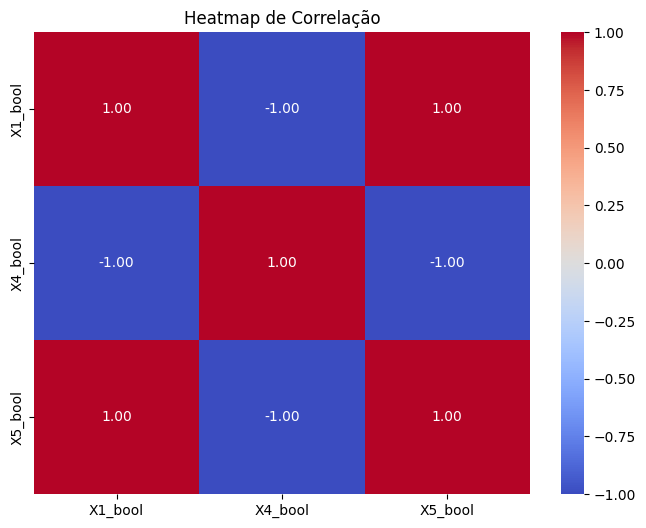

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

# Criar um DataFrame com as variáveis de interesse
correlation_data = X[['X1_bool', 'X4_bool', 'X5_bool']].corr()

# Criar o heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_data, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap de Correlação")
plt.show()

Portanto, com base nos resultados da análise exploratória, foram definidos dois conjuntos de variáveis preditoras. Sendo uma delas, o conjunto com todas as variáveis originais, apenas para fins de comparação.

1. **Baseline:** inclui todas as oito variáveis preditoras originais.
2. **Features Selecionadas** inclui apenas as variáveis selecionadas através da análise exploratória dos dados.

In [61]:
# Conjunto de preditores
features_baseline = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']
features_enginnering = ['X3', 'X4_bool', 'X7']

#### 1.2 Preparação dos conjuntos X e y

In [62]:
# TARGETS
y_Y1 = y['Y1']
y_Y2 = y['Y2']

# Dicionário para armazenar os conjuntos de features
X_sets = {}

# Conjuntos de features
X_sets['baseline'] = X[features_baseline]
X_sets['engineering'] = X[features_enginnering]

In [63]:
X_sets

{'baseline':        X1     X2     X3      X4   X5  X6   X7  X8
 0    0.98  514.5  294.0  110.25  7.0   2  0.0   0
 1    0.98  514.5  294.0  110.25  7.0   3  0.0   0
 2    0.98  514.5  294.0  110.25  7.0   4  0.0   0
 3    0.98  514.5  294.0  110.25  7.0   5  0.0   0
 4    0.90  563.5  318.5  122.50  7.0   2  0.0   0
 ..    ...    ...    ...     ...  ...  ..  ...  ..
 763  0.64  784.0  343.0  220.50  3.5   5  0.4   5
 764  0.62  808.5  367.5  220.50  3.5   2  0.4   5
 765  0.62  808.5  367.5  220.50  3.5   3  0.4   5
 766  0.62  808.5  367.5  220.50  3.5   4  0.4   5
 767  0.62  808.5  367.5  220.50  3.5   5  0.4   5
 
 [768 rows x 8 columns],
 'engineering':         X3  X4_bool   X7
 0    294.0     True  0.0
 1    294.0     True  0.0
 2    294.0     True  0.0
 3    294.0     True  0.0
 4    318.5     True  0.0
 ..     ...      ...  ...
 763  343.0    False  0.4
 764  367.5    False  0.4
 765  367.5    False  0.4
 766  367.5    False  0.4
 767  367.5    False  0.4
 
 [768 rows x 3 colum

#### 1.5 Divisão em treino, validação e teste

In [64]:
from sklearn.model_selection import train_test_split

# Divisão será realizada apenas com os índices, que será usada para todos os conjuntos
idx_treino, idx_temp = train_test_split(X.index, test_size=0.4, random_state=42)
idx_validacao, idx_teste = train_test_split(idx_temp, test_size=0.5, random_state=42)

print("Tamanho treino:", len(idx_treino))
print("Tamanho validação:", len(idx_validacao))
print("Tamanho teste:", len(idx_teste))

Tamanho treino: 460
Tamanho validação: 154
Tamanho teste: 154


#### 1.6 Padronização dos dados

Para garantir consistência e eficiência no treinamento dos modelos, aplicamos diferentes técnicas de padronização:

- Variáveis float64: Utilizamos o StandardScaler para normalizar os dados, ajustando-os para média zero e desvio padrão igual a um.
- Variáveis int64: Aplicamos o OneHotEncoder para transformar variáveis categóricas em representações binárias, eliminando colinearidade.
- Variáveis booleanas: Mantivemos inalteradas, pois já estão em formato adequado.

Essa abordagem assegura que os dados estejam otimizados para os modelos, reduzindo vieses causados por escalas diferentes e melhorando a eficiência do processo.

In [65]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   X1       768 non-null    float64
 1   X2       768 non-null    float64
 2   X3       768 non-null    float64
 3   X4       768 non-null    float64
 4   X5       768 non-null    float64
 5   X6       768 non-null    int64  
 6   X7       768 non-null    float64
 7   X8       768 non-null    int64  
 8   X1_bool  768 non-null    bool   
 9   X4_bool  768 non-null    bool   
 10  X5_bool  768 non-null    bool   
dtypes: bool(3), float64(6), int64(2)
memory usage: 50.4 KB


In [69]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd
import pickle
import os

def padronizar(X_full, y, idx_train, idx_val, idx_test, nome_conjunto):
    # Separar os índices de treino, validação e teste
    X_train = X_full.loc[idx_train]
    X_val = X_full.loc[idx_val]
    X_test = X_full.loc[idx_test]

    # Identificar os tipos de variáveis
    float_cols = X_full.select_dtypes(include=['float64']).columns
    int_cols = X_full.select_dtypes(include=['int64']).columns
    bool_cols = X_full.select_dtypes(include=['bool']).columns

    # Aplicar StandardScaler para variáveis float64
    scaler = StandardScaler()
    X_train_float = pd.DataFrame(scaler.fit_transform(X_train[float_cols]), columns=float_cols, index=X_train.index)
    X_val_float = pd.DataFrame(scaler.transform(X_val[float_cols]), columns=float_cols, index=X_val.index)
    X_test_float = pd.DataFrame(scaler.transform(X_test[float_cols]), columns=float_cols, index=X_test.index)

    # Aplicar OneHotEncoder para variáveis int64
    encoder = OneHotEncoder(drop='first', sparse_output=False)
    X_train_int = pd.DataFrame(encoder.fit_transform(X_train[int_cols]), 
                               columns=encoder.get_feature_names_out(int_cols), index=X_train.index)
    X_val_int = pd.DataFrame(encoder.transform(X_val[int_cols]), 
                             columns=encoder.get_feature_names_out(int_cols), index=X_val.index)
    X_test_int = pd.DataFrame(encoder.transform(X_test[int_cols]), 
                              columns=encoder.get_feature_names_out(int_cols), index=X_test.index)

    # Manter as variáveis booleanas inalteradas
    X_train_bool = X_train[bool_cols]
    X_val_bool = X_val[bool_cols]
    X_test_bool = X_test[bool_cols]

    # Concatenar os resultados
    X_train_scaled = pd.concat([X_train_float, X_train_int, X_train_bool], axis=1)
    X_val_scaled = pd.concat([X_val_float, X_val_int, X_val_bool], axis=1)
    X_test_scaled = pd.concat([X_test_float, X_test_int, X_test_bool], axis=1)

    # Salvar scaler e encoder automaticamente na pasta 'scalar_encoder'
    model_dir = os.path.join(os.getcwd(), 'scalar_encoder')
    os.makedirs(model_dir, exist_ok=True)

    scaler_path = os.path.join(model_dir, f'scaler_{nome_conjunto}.pkl')
    encoder_path = os.path.join(model_dir, f'encoder_{nome_conjunto}.pkl')

    with open(scaler_path, 'wb') as f:
        pickle.dump(scaler, f)

    with open(encoder_path, 'wb') as f:
        pickle.dump(encoder, f)

    print(f"Scaler salvo em: {scaler_path}")
    print(f"Encoder salvo em: {encoder_path}")

    # Targets
    y_train = y.loc[idx_train]
    y_val = y.loc[idx_val]
    y_test = y.loc[idx_test]

    return X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test

In [70]:
# Dicionário para armazenar os conjuntos já padronizados
datasets = {}

# Para cada combinação de features
for nome, X_feat in X_sets.items():
    X_train, X_val, X_test, y_train, y_val, y_test = padronizar(X_feat, y, idx_treino, idx_validacao, idx_teste, nome)
    datasets[nome] = {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test
    }

Scaler salvo em: c:\Users\weslleygsantos\Desktop\CASE_IA\modeling_and_evaluation\scalar_encoder\scaler_baseline.pkl
Encoder salvo em: c:\Users\weslleygsantos\Desktop\CASE_IA\modeling_and_evaluation\scalar_encoder\encoder_baseline.pkl
Scaler salvo em: c:\Users\weslleygsantos\Desktop\CASE_IA\modeling_and_evaluation\scalar_encoder\scaler_engineering.pkl
Encoder salvo em: c:\Users\weslleygsantos\Desktop\CASE_IA\modeling_and_evaluation\scalar_encoder\encoder_engineering.pkl


In [12]:
datasets['baseline']['X_train'].head()

,X1,X2,X3,X4,X5,X7,X6_3,X6_4,X6_5,X8_1,X8_2,X8_3,X8_4,X8_5
426,-1.172982,1.279854,0.569541,0.959812,-0.98704,0.110320,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
9,0.918381,-0.964007,-0.542938,-0.667388,1.01313,-1.755384,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
249,0.918381,-0.964007,-0.542938,-0.667388,1.01313,-1.009102,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
22,-0.032238,-0.122559,2.238259,-1.209788,1.01313,-1.755384,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
221,-0.507548,0.438407,-1.099178,0.959812,-0.98704,-1.009102,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [13]:
datasets['engineering']['X_train'].head()

,X3,X7,X4_bool
426,0.569541,0.110320,False
9,-0.542938,-1.755384,True
249,-0.542938,-1.009102,True
22,2.238259,-1.755384,True
221,-1.099178,-1.009102,False


In [14]:
datasets['baseline']['y_test'].head()

,Y1,Y2
381,14.66,15.64
148,28.07,34.14
494,24.60,29.31
754,14.37,16.54
209,35.89,43.30


### 2. Modelagem e avaliação de algoritmos

Selecionamos cinco modelos distintos para avaliação: Regressão Linear Multivariada, K-Nearest Neighbors (KNN), Decision Tree Regressor, Random Forest Regressor e XGBoost Regressor. Esses modelos foram treinados e avaliados utilizando os conjuntos de features selecionados e o baseline, comparando métricas como RMSE, MAE e R² para identificar o melhor desempenho.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def calcular_metricas(y_true, y_pred, X_train):
    """
    Calcula RMSE, MAE, R2 e R2 ajustado.
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    n = len(y_true)
    p = X_train.shape[1]
    adj_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

    return rmse, mae, r2, adj_r2

def extrair_dados(dados):
    """
    Extrai os conjuntos de treino e validação de um dicionário de dados.
    """
    X_train = dados['X_train']
    X_val = dados['X_val']
    y_train = dados['y_train']
    y_val = dados['y_val']
    return X_train, X_val, y_train, y_val

#### 2.1 Regressão Linear Multivariada


In [ ]:
from sklearn.linear_model import LinearRegression

def linear_regression(datasets):
    """
    Treina modelos de regressão linear multivariada para diferentes conjuntos de dados
    e seleciona o melhor com base no menor RMSE.
    """
    resultados = {}
    melhor_rmse = float('inf')
    melhor_feature_lr = None

    for nome, dados in datasets.items():
        # Extrair os conjuntos de treino e validação
        X_train, X_val, y_train, y_val = extrair_dados(dados)

        # Certificar-se de que y_train e y_val são matrizes
        y_train = y_train[['Y1', 'Y2']].values
        y_val = y_val[['Y1', 'Y2']].values

        # Treinar o modelo de regressão linear multivariada
        modelo = LinearRegression()
        modelo.fit(X_train, y_train)

        # Fazer predições para o conjunto de validação
        y_val_pred = modelo.predict(X_val)

        # Calcular métricas para Y1
        rmse_Y1, mae_Y1, r2_Y1, adj_r2_Y1 = calcular_metricas(y_val[:, 0], y_val_pred[:, 0], X_train)

        # Calcular métricas para Y2
        rmse_Y2, mae_Y2, r2_Y2, adj_r2_Y2 = calcular_metricas(y_val[:, 1], y_val_pred[:, 1], X_train)

        # Calcular o RMSE médio
        rmse_medio = (rmse_Y1 + rmse_Y2) / 2

        # Armazenar os resultados
        resultados[nome] = {
            'modelo': modelo,
            'RMSE_Y1': rmse_Y1,
            'MAE_Y1': mae_Y1,
            'R2_Y1': r2_Y1,
            'Adj_R2_Y1': adj_r2_Y1,
            'RMSE_Y2': rmse_Y2,
            'MAE_Y2': mae_Y2,
            'R2_Y2': r2_Y2,
            'Adj_R2_Y2': adj_r2_Y2,
            'RMSE_Medio': rmse_medio
        }

        # Atualizar o melhor conjunto de features
        if rmse_medio < melhor_rmse:
            melhor_rmse = rmse_medio
            melhor_feature_lr = nome

    return melhor_feature_lr, resultados

In [33]:
# Encontrar o melhor modelo de regressão linear multivariada
melhor_feature_lr, resultados_lr = linear_regression(datasets)

# Exibir os resultados
print(f"Melhor conjunto de features: {melhor_feature_lr}")
for nome, res in resultados_lr.items():
    print(f"\nResultados para {nome}:")
    print(f"Y1 - RMSE: {res['RMSE_Y1']:.3f}, MAE: {res['MAE_Y1']:.3f}, R2: {res['R2_Y1']:.3f}, Adj R2: {res['Adj_R2_Y1']:.3f}")
    print(f"Y2 - RMSE: {res['RMSE_Y2']:.3f}, MAE: {res['MAE_Y2']:.3f}, R2: {res['R2_Y2']:.3f}, Adj R2: {res['Adj_R2_Y2']:.3f}")
    print(f"RMSE Médio: {res['RMSE_Medio']:.3f}")

Melhor conjunto de features: baseline

Resultados para baseline:
Y1 - RMSE: 2.978, MAE: 2.150, R2: 0.917, Adj R2: 0.909
Y2 - RMSE: 2.736, MAE: 2.020, R2: 0.914, Adj R2: 0.905
RMSE Médio: 2.857

Resultados para engineering:
Y1 - RMSE: 3.344, MAE: 2.407, R2: 0.895, Adj R2: 0.893
Y2 - RMSE: 2.962, MAE: 2.216, R2: 0.899, Adj R2: 0.897
RMSE Médio: 3.153


In [52]:
# Recuperar o melhor modelo
melhor_modelo_lr = resultados_lr[melhor_feature_lr]['modelo']  

# Exibir os parâmetros do melhor modelo
print("\nParâmetros do melhor modelo de Regressão Linear:")
print(melhor_modelo_lr.get_params())


Parâmetros do melhor modelo de Regressão Linear:
{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}


#### 3. K-Nearest Neighbors Regressor (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

def knn_gridsearch(datasets, param_grid):
    """
    Treina modelos KNN com busca em grade (GridSearch) para diferentes conjuntos de dados
    e seleciona o melhor com base no menor RMSE médio para regressão multivariada.
    """
    resultados = {}
    melhor_rmse_medio = float('inf')
    melhor_feature_knn = None

    for nome, dados in datasets.items():
        # Extrair os conjuntos de treino e validação
        X_train, X_val, y_train, y_val = extrair_dados(dados)

        # Certificar-se de que y_train e y_val são matrizes (para multivariada)
        y_train = y_train[['Y1', 'Y2']].values
        y_val = y_val[['Y1', 'Y2']].values

        # Inicializar o modelo KNN
        knn = KNeighborsRegressor()

        # Realizar o GridSearch com os parâmetros especificados
        grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
        grid_search.fit(X_train, y_train)

        # Obter o melhor modelo e seus parâmetros
        melhor_knn_model = grid_search.best_estimator_
        melhor_params = grid_search.best_params_

        # Fazer predições no conjunto de validação
        y_val_pred = melhor_knn_model.predict(X_val)

        # Calcular métricas para Y1
        rmse_Y1, mae_Y1, r2_Y1, adj_r2_Y1 = calcular_metricas(y_val[:, 0], y_val_pred[:, 0], X_train)

        # Calcular métricas para Y2
        rmse_Y2, mae_Y2, r2_Y2, adj_r2_Y2 = calcular_metricas(y_val[:, 1], y_val_pred[:, 1], X_train)

        # Calcular o RMSE médio
        rmse_medio = (rmse_Y1 + rmse_Y2) / 2

        # Armazenar os resultados
        resultados[nome] = {
            'modelo': melhor_knn_model,
            'melhor_params': melhor_params,
            'RMSE_Y1': rmse_Y1,
            'MAE_Y1': mae_Y1,
            'R2_Y1': r2_Y1,
            'Adj_R2_Y1': adj_r2_Y1,
            'RMSE_Y2': rmse_Y2,
            'MAE_Y2': mae_Y2,
            'R2_Y2': r2_Y2,
            'Adj_R2_Y2': adj_r2_Y2,
            'RMSE_Medio': rmse_medio
        }

        # Atualizar o melhor conjunto de features
        if rmse_medio < melhor_rmse_medio:
            melhor_rmse_medio = rmse_medio
            melhor_feature_knn = nome

    return melhor_feature_knn, resultados

In [36]:
# Definir o grid de parâmetros para o GridSearch
param_grid = {
    'n_neighbors': list(range(1, 11)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Treinar o modelo KNN para regressão multivariada
melhor_feature_knn, resultados_knn = knn_gridsearch(datasets, param_grid)

# Exibir os resultados
print(f"Melhor conjunto de features: {melhor_feature_knn}")
for nome, res in resultados_knn.items():
    print(f"\nResultados para {nome}:")
    print(f"Y1 - RMSE: {res['RMSE_Y1']:.3f}, MAE: {res['MAE_Y1']:.3f}, R2: {res['R2_Y1']:.3f}, Adj R2: {res['Adj_R2_Y1']:.3f}")
    print(f"Y2 - RMSE: {res['RMSE_Y2']:.3f}, MAE: {res['MAE_Y2']:.3f}, R2: {res['R2_Y2']:.3f}, Adj R2: {res['Adj_R2_Y2']:.3f}")
    print(f"RMSE Médio: {res['RMSE_Medio']:.3f}")
    print(f"Melhores parâmetros: {res['melhor_params']}")

Melhor conjunto de features: baseline

Resultados para baseline:
Y1 - RMSE: 1.868, MAE: 1.200, R2: 0.967, Adj R2: 0.964
Y2 - RMSE: 1.837, MAE: 1.277, R2: 0.961, Adj R2: 0.957
RMSE Médio: 1.853
Melhores parâmetros: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}

Resultados para engineering:
Y1 - RMSE: 1.599, MAE: 0.946, R2: 0.976, Adj R2: 0.976
Y2 - RMSE: 2.465, MAE: 1.502, R2: 0.930, Adj R2: 0.929
RMSE Médio: 2.032
Melhores parâmetros: {'metric': 'euclidean', 'n_neighbors': 10, 'weights': 'distance'}


In [51]:
# Recuperar o melhor modelo
melhor_modelo_knn = resultados_knn[melhor_feature_knn]['modelo']

# Exibir os parâmetros do melhor modelo
print("\nParâmetros do melhor modelo KNN:")
print(melhor_modelo_knn.get_params())


Parâmetros do melhor modelo KNN:
{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'manhattan', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


#### 4. Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

def decision_tree_gridsearch(datasets, param_grid):
    """
    Treina modelos de árvore de regressão multivariada para diferentes conjuntos de dados
    e seleciona o melhor com base no menor RMSE médio.
    """
    resultados = {}
    melhor_rmse_medio = float('inf')
    melhor_feature_tree = None

    for nome, dados in datasets.items():
        # Extrair os conjuntos de treino e validação
        X_train, X_val, y_train, y_val = extrair_dados(dados)

        # Certificar-se de que y_train e y_val são matrizes (para multivariada)
        y_train = y_train[['Y1', 'Y2']].values
        y_val = y_val[['Y1', 'Y2']].values

        # Inicializar o modelo de árvore de decisão
        tree = DecisionTreeRegressor(random_state=42)

        # Realizar o GridSearch com os parâmetros especificados
        grid_search = GridSearchCV(tree, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
        grid_search.fit(X_train, y_train)

        # Obter o melhor modelo e seus parâmetros
        melhor_tree_model = grid_search.best_estimator_
        melhor_params = grid_search.best_params_

        # Fazer predições no conjunto de validação
        y_val_pred = melhor_tree_model.predict(X_val)

        # Calcular métricas para Y1
        rmse_Y1, mae_Y1, r2_Y1, adj_r2_Y1 = calcular_metricas(y_val[:, 0], y_val_pred[:, 0], X_train)

        # Calcular métricas para Y2
        rmse_Y2, mae_Y2, r2_Y2, adj_r2_Y2 = calcular_metricas(y_val[:, 1], y_val_pred[:, 1], X_train)

        # Calcular o RMSE médio
        rmse_medio = (rmse_Y1 + rmse_Y2) / 2

        # Armazenar os resultados
        resultados[nome] = {
            'modelo': melhor_tree_model,
            'melhor_params': melhor_params,
            'RMSE_Y1': rmse_Y1,
            'MAE_Y1': mae_Y1,
            'R2_Y1': r2_Y1,
            'Adj_R2_Y1': adj_r2_Y1,
            'RMSE_Y2': rmse_Y2,
            'MAE_Y2': mae_Y2,
            'R2_Y2': r2_Y2,
            'Adj_R2_Y2': adj_r2_Y2,
            'RMSE_Medio': rmse_medio
        }

        # Atualizar o melhor conjunto de testes
        if rmse_medio < melhor_rmse_medio:
            melhor_rmse_medio = rmse_medio
            melhor_feature_tree = nome

    return melhor_feature_tree, resultados

In [39]:
# Definir o grid de parâmetros para o GridSearch
param_grid = {
    'max_depth': list(range(1, 11)),
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Treinar o modelo de árvore de decisão para regressão multivariada
melhor_feature_tree, resultados_tree = decision_tree_gridsearch(datasets, param_grid)

# Exibir os resultados
print(f"\nMelhor conjunto de features: {melhor_feature_tree}")
for nome, res in resultados_tree.items():
    print(f"\nResultados para {nome}:")
    print(f"Y1 - RMSE: {res['RMSE_Y1']:.3f}, MAE: {res['MAE_Y1']:.3f}, R2: {res['R2_Y1']:.3f}, Adj R2: {res['Adj_R2_Y1']:.3f}")
    print(f"Y2 - RMSE: {res['RMSE_Y2']:.3f}, MAE: {res['MAE_Y2']:.3f}, R2: {res['R2_Y2']:.3f}, Adj R2: {res['Adj_R2_Y2']:.3f}")
    print(f"RMSE Médio: {res['RMSE_Medio']:.3f}")
    print(f"Melhores parâmetros: {res['melhor_params']}")


Melhor conjunto de features: baseline

Resultados para baseline:
Y1 - RMSE: 0.674, MAE: 0.441, R2: 0.996, Adj R2: 0.995
Y2 - RMSE: 1.940, MAE: 1.206, R2: 0.957, Adj R2: 0.952
RMSE Médio: 1.307
Melhores parâmetros: {'max_depth': 8, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10}

Resultados para engineering:
Y1 - RMSE: 1.489, MAE: 0.907, R2: 0.979, Adj R2: 0.979
Y2 - RMSE: 2.268, MAE: 1.431, R2: 0.941, Adj R2: 0.940
RMSE Médio: 1.878
Melhores parâmetros: {'max_depth': 8, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [50]:
# Selecionar o melhor modelo
melhor_modelo_tree = resultados_tree[melhor_feature_tree]['modelo']

# Exibir os parâmetros do melhor modelo
print("\nParâmetros do melhor modelo de Decision Tree:")
print(melhor_modelo_tree.get_params())


Parâmetros do melhor modelo de Decision Tree:
{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 8, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 4, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


#### 5. Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

def random_forest_gridsearch(datasets, param_grid):
    """
    Treina modelos Random Forest Regressor com GridSearchCV para diferentes conjuntos de dados
    e seleciona o melhor com base no menor RMSE médio.
    """
    resultados = {}
    melhor_rmse_medio = float('inf')
    melhor_feature_rf = None

    for nome, dados in datasets.items():
        # Extrair os conjuntos de treino e validação
        X_train, X_val, y_train, y_val = extrair_dados(dados)

        # Certificar-se de que y_train e y_val são matrizes (para multivariada)
        y_train = y_train[['Y1', 'Y2']].values
        y_val = y_val[['Y1', 'Y2']].values

        # Inicializar o modelo Random Forest
        rf = RandomForestRegressor(random_state=42)

        # Realizar o GridSearch com os parâmetros especificados
        grid_search = GridSearchCV(
            rf, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
        )
        grid_search.fit(X_train, y_train)

        # Obter o melhor modelo e seus parâmetros
        melhor_rf_model = grid_search.best_estimator_
        melhor_params = grid_search.best_params_

        # Fazer predições no conjunto de validação
        y_val_pred = melhor_rf_model.predict(X_val)

        # Calcular métricas para Y1
        rmse_Y1, mae_Y1, r2_Y1, adj_r2_Y1 = calcular_metricas(y_val[:, 0], y_val_pred[:, 0], X_train)

        # Calcular métricas para Y2
        rmse_Y2, mae_Y2, r2_Y2, adj_r2_Y2 = calcular_metricas(y_val[:, 1], y_val_pred[:, 1], X_train)

        # Calcular o RMSE médio
        rmse_medio = (rmse_Y1 + rmse_Y2) / 2

        # Armazenar os resultados
        resultados[nome] = {
            'modelo': melhor_rf_model,
            'melhor_params': melhor_params,
            'RMSE_Y1': rmse_Y1,
            'MAE_Y1': mae_Y1,
            'R2_Y1': r2_Y1,
            'Adj_R2_Y1': adj_r2_Y1,
            'RMSE_Y2': rmse_Y2,
            'MAE_Y2': mae_Y2,
            'R2_Y2': r2_Y2,
            'Adj_R2_Y2': adj_r2_Y2,
            'RMSE_Medio': rmse_medio
        }

        # Atualizar o melhor conjunto e testes
        if rmse_medio < melhor_rmse_medio:
            melhor_rmse_medio = rmse_medio
            melhor_feature_rf = nome

    return melhor_feature_rf, resultados

In [42]:
# Definir o grid de parâmetros para o GridSearch
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Treinar o modelo Random Forest para regressão multivariada
melhor_feature_rf, resultados_rf = random_forest_gridsearch(datasets, param_grid)

# Exibir os resultados
print(f"Melhor conjunto de features: {melhor_feature_rf}")
for nome, res in resultados_rf.items():
    print(f"\nResultados para {nome}:")
    print(f"Y1 - RMSE: {res['RMSE_Y1']:.3f}, MAE: {res['MAE_Y1']:.3f}, R2: {res['R2_Y1']:.3f}, Adj R2: {res['Adj_R2_Y1']:.3f}")
    print(f"Y2 - RMSE: {res['RMSE_Y2']:.3f}, MAE: {res['MAE_Y2']:.3f}, R2: {res['R2_Y2']:.3f}, Adj R2: {res['Adj_R2_Y2']:.3f}")
    print(f"RMSE Médio: {res['RMSE_Medio']:.3f}")
    print(f"Melhores parâmetros: {res['melhor_params']}")

Melhor conjunto de features: baseline

Resultados para baseline:
Y1 - RMSE: 0.602, MAE: 0.418, R2: 0.997, Adj R2: 0.996
Y2 - RMSE: 2.028, MAE: 1.239, R2: 0.953, Adj R2: 0.948
RMSE Médio: 1.315
Melhores parâmetros: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Resultados para engineering:
Y1 - RMSE: 1.492, MAE: 0.908, R2: 0.979, Adj R2: 0.979
Y2 - RMSE: 2.282, MAE: 1.441, R2: 0.940, Adj R2: 0.939
RMSE Médio: 1.887
Melhores parâmetros: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [49]:
# Selecionar o melhor modelo
melhor_modelo_rf = resultados_rf[melhor_feature_rf]['modelo']

# Exibir os parâmetros do melhor modelo
print("\nParâmetros do melhor modelo de Random Forest:")
print(melhor_modelo_rf.get_params())


Parâmetros do melhor modelo de Random Forest:
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


#### 6. XGBoost Regressor

In [44]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

def xgboost_gridsearch(datasets, param_grid):
    """
    Treina modelos XGBoost Regressor com GridSearchCV para diferentes conjuntos de dados
    e seleciona o melhor com base no menor RMSE médio.
    """
    resultados = {}
    melhor_rmse_medio = float('inf')
    melhor_feature_xgb = None

    for nome, dados in datasets.items():
        # Extrair os conjuntos de treino e validação
        X_train, X_val, y_train, y_val = extrair_dados(dados)

        # Certificar-se de que y_train e y_val são matrizes (para multivariada)
        y_train = y_train[['Y1', 'Y2']].values
        y_val = y_val[['Y1', 'Y2']].values

        # Inicializar o modelo XGBoost
        xgb = XGBRegressor(random_state=42, objective='reg:squarederror', verbosity=0)

        # Realizar o GridSearch com os parâmetros especificados
        grid_search = GridSearchCV(
            xgb, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
        )
        grid_search.fit(X_train, y_train)

        # Obter o melhor modelo e seus parâmetros
        melhor_xgb_model = grid_search.best_estimator_
        melhor_params = grid_search.best_params_

        # Fazer predições no conjunto de validação
        y_val_pred = melhor_xgb_model.predict(X_val)

        # Calcular métricas para Y1
        rmse_Y1, mae_Y1, r2_Y1, adj_r2_Y1 = calcular_metricas(y_val[:, 0], y_val_pred[:, 0], X_train)

        # Calcular métricas para Y2
        rmse_Y2, mae_Y2, r2_Y2, adj_r2_Y2 = calcular_metricas(y_val[:, 1], y_val_pred[:, 1], X_train)

        # Calcular o RMSE médio
        rmse_medio = (rmse_Y1 + rmse_Y2) / 2

        # Armazenar os resultados
        resultados[nome] = {
            'modelo': melhor_xgb_model,
            'melhor_params': melhor_params,
            'RMSE_Y1': rmse_Y1,
            'MAE_Y1': mae_Y1,
            'R2_Y1': r2_Y1,
            'Adj_R2_Y1': adj_r2_Y1,
            'RMSE_Y2': rmse_Y2,
            'MAE_Y2': mae_Y2,
            'R2_Y2': r2_Y2,
            'Adj_R2_Y2': adj_r2_Y2,
            'RMSE_Medio': rmse_medio
        }

        # Atualizar o melhor conjunto de testes
        if rmse_medio < melhor_rmse_medio:
            melhor_rmse_medio = rmse_medio
            melhor_feature_xgb = nome

    return melhor_feature_xgb, resultados

In [45]:
# Definir o grid de parâmetros para o GridSearch
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 10, 100]
}

# Treinar o modelo XGBoost para regressão multivariada
melhor_feature_xgb, resultados_xgb = xgboost_gridsearch(datasets, param_grid)

# Exibir os resultados
print(f"Melhor conjunto de features: {melhor_feature_xgb}")
for nome, res in resultados_xgb.items():
    print(f"\nResultados para {nome}:")
    print(f"Y1 - RMSE: {res['RMSE_Y1']:.3f}, MAE: {res['MAE_Y1']:.3f}, R2: {res['R2_Y1']:.3f}, Adj R2: {res['Adj_R2_Y1']:.3f}")
    print(f"Y2 - RMSE: {res['RMSE_Y2']:.3f}, MAE: {res['MAE_Y2']:.3f}, R2: {res['R2_Y2']:.3f}, Adj R2: {res['Adj_R2_Y2']:.3f}")
    print(f"RMSE Médio: {res['RMSE_Medio']:.3f}")
    print(f"Melhores parâmetros: {res['melhor_params']}")

Melhor conjunto de features: baseline

Resultados para baseline:
Y1 - RMSE: 0.475, MAE: 0.343, R2: 0.998, Adj R2: 0.998
Y2 - RMSE: 1.579, MAE: 1.030, R2: 0.971, Adj R2: 0.969
RMSE Médio: 1.027
Melhores parâmetros: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda': 1}

Resultados para engineering:
Y1 - RMSE: 1.500, MAE: 0.926, R2: 0.979, Adj R2: 0.979
Y2 - RMSE: 2.205, MAE: 1.417, R2: 0.944, Adj R2: 0.943
RMSE Médio: 1.852
Melhores parâmetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 1}


In [48]:
# Selecionar o melhor modelo
melhor_modelo_xgb = resultados_xgb[melhor_feature_xgb]['modelo']

# Exibir os parâmetros do melhor modelo
print("\nParâmetros do melhor modelo de XGBoost:")
print(melhor_modelo_xgb.get_params())


Parâmetros do melhor modelo de XGBoost:
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.2, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 3, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 200, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.1, 'reg_lambda': 1, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': 0}


#### 7. Avaliação dos melhores modelos no conjunto de testes

In [54]:
melhores_modelos = [melhor_modelo_lr, melhor_modelo_knn, melhor_modelo_rf, melhor_modelo_tree, melhor_modelo_xgb]

# Lista de nomes dos modelos
nomes_modelos = ['Regressão Linear', 'KNN', 'Random Forest', 'Decision Tree', 'XGBoost']

# Dicionário para armazenar os resultados finais
resultados_finais = {}

# Loop para avaliar cada modelo no conjunto de testes
for nome, modelo, melhor_feature in zip(
    nomes_modelos,
    melhores_modelos,
    [melhor_feature_lr, melhor_feature_knn, melhor_feature_rf, melhor_feature_tree, melhor_feature_xgb]
):
    # Acessar os conjuntos de teste
    X_teste = datasets[melhor_feature]['X_test']
    y_teste = datasets[melhor_feature]['y_test']

    # Fazer predições
    y_pred = modelo.predict(X_teste)

    # Calcular métricas para Y1
    rmse_Y1, mae_Y1, r2_Y1, adj_r2_Y1 = calcular_metricas(y_teste['Y1'], y_pred[:, 0], X_teste)

    # Calcular métricas para Y2
    rmse_Y2, mae_Y2, r2_Y2, adj_r2_Y2 = calcular_metricas(y_teste['Y2'], y_pred[:, 1], X_teste)

    # Calcular o RMSE médio
    rmse_medio = (rmse_Y1 + rmse_Y2) / 2

    # Armazenar os resultados
    resultados_finais[nome] = {
        'RMSE_Y1': rmse_Y1,
        'MAE_Y1': mae_Y1,
        'R2_Y1': r2_Y1,
        'Adj_R2_Y1': adj_r2_Y1,
        'RMSE_Y2': rmse_Y2,
        'MAE_Y2': mae_Y2,
        'R2_Y2': r2_Y2,
        'Adj_R2_Y2': adj_r2_Y2,
        'RMSE_Medio': rmse_medio
    }

# Selecionar o melhor modelo com base no menor RMSE médio
melhor_modelo = min(resultados_finais, key=lambda x: resultados_finais[x]['RMSE_Medio'])

# Exibir os resultados finais
print("Resultados finais no conjunto de testes:")
for nome, res in resultados_finais.items():
    print(f"\nModelo: {nome}")
    print(f"Y1 - RMSE: {res['RMSE_Y1']:.3f}, MAE: {res['MAE_Y1']:.3f}, R2: {res['R2_Y1']:.3f}, Adj R2: {res['Adj_R2_Y1']:.3f}")
    print(f"Y2 - RMSE: {res['RMSE_Y2']:.3f}, MAE: {res['MAE_Y2']:.3f}, R2: {res['R2_Y2']:.3f}, Adj R2: {res['Adj_R2_Y2']:.3f}")
    print(f"RMSE Médio: {res['RMSE_Medio']:.3f}")

print(f"\nMelhor modelo: {melhor_modelo} com RMSE Médio: {resultados_finais[melhor_modelo]['RMSE_Medio']:.3f}")

Resultados finais no conjunto de testes:

Modelo: Regressão Linear
Y1 - RMSE: 2.809, MAE: 2.036, R2: 0.920, Adj R2: 0.912
Y2 - RMSE: 3.411, MAE: 2.492, R2: 0.875, Adj R2: 0.862
RMSE Médio: 3.110

Modelo: KNN
Y1 - RMSE: 1.501, MAE: 1.088, R2: 0.977, Adj R2: 0.975
Y2 - RMSE: 2.040, MAE: 1.409, R2: 0.955, Adj R2: 0.951
RMSE Médio: 1.770

Modelo: Random Forest
Y1 - RMSE: 0.463, MAE: 0.344, R2: 0.998, Adj R2: 0.998
Y2 - RMSE: 1.896, MAE: 1.253, R2: 0.961, Adj R2: 0.957
RMSE Médio: 1.180

Modelo: Decision Tree
Y1 - RMSE: 0.530, MAE: 0.391, R2: 0.997, Adj R2: 0.997
Y2 - RMSE: 1.817, MAE: 1.203, R2: 0.965, Adj R2: 0.961
RMSE Médio: 1.173

Modelo: XGBoost
Y1 - RMSE: 0.405, MAE: 0.315, R2: 0.998, Adj R2: 0.998
Y2 - RMSE: 1.312, MAE: 0.962, R2: 0.982, Adj R2: 0.980
RMSE Médio: 0.859

Melhor modelo: XGBoost com RMSE Médio: 0.859


In [56]:
import pickle

# Salvar o melhor modelo em um arquivo .pkl
with open('melhor_modelo.pkl', 'wb') as file:
    pickle.dump(melhor_modelo_xgb, file)

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


Entre os cinco modelos testados, o conjunto de features que utilizou todas as variáveis preditoras apresentou o melhor desempenho. Contudo, por curiosidade, também avaliaremos os cinco modelos no conjunto de testes utilizando o conjunto de features selecionadas com base na análise exploratória.

In [55]:
# Lista de modelos e seus nomes
modelos_engineering = [
    resultados_lr['engineering']['modelo'],
    resultados_knn['engineering']['modelo'],
    resultados_rf['engineering']['modelo'],
    resultados_tree['engineering']['modelo'],
    resultados_xgb['engineering']['modelo']
]

nomes_modelos = ['Regressão Linear', 'KNN', 'Random Forest', 'Decision Tree', 'XGBoost']

# Dicionário para armazenar os resultados finais
resultados_finais = {}

# Acessar os conjuntos de teste
X_teste = datasets['engineering']['X_test']
y_teste = datasets['engineering']['y_test']

# Avaliar cada modelo
for nome, modelo in zip(nomes_modelos, modelos_engineering):
    # Fazer predições
    y_pred = modelo.predict(X_teste)

    # Calcular métricas para Y1 e Y2
    rmse_Y1, mae_Y1, r2_Y1, adj_r2_Y1 = calcular_metricas(y_teste['Y1'], y_pred[:, 0], X_teste)
    rmse_Y2, mae_Y2, r2_Y2, adj_r2_Y2 = calcular_metricas(y_teste['Y2'], y_pred[:, 1], X_teste)

    # Calcular o RMSE médio
    rmse_medio = (rmse_Y1 + rmse_Y2) / 2

    # Armazenar os resultados
    resultados_finais[nome] = {
        'RMSE_Y1': rmse_Y1,
        'MAE_Y1': mae_Y1,
        'R2_Y1': r2_Y1,
        'Adj_R2_Y1': adj_r2_Y1,
        'RMSE_Y2': rmse_Y2,
        'MAE_Y2': mae_Y2,
        'R2_Y2': r2_Y2,
        'Adj_R2_Y2': adj_r2_Y2,
        'RMSE_Medio': rmse_medio
    }

# Selecionar o melhor modelo com base no menor RMSE médio
melhor_modelo = min(resultados_finais, key=lambda x: resultados_finais[x]['RMSE_Medio'])

# Exibir os resultados finais
print("Resultados finais no conjunto de testes:")
for nome, res in resultados_finais.items():
    print(f"\nModelo: {nome}")
    print(f"Y1 - RMSE: {res['RMSE_Y1']:.3f}, MAE: {res['MAE_Y1']:.3f}, R2: {res['R2_Y1']:.3f}, Adj R2: {res['Adj_R2_Y1']:.3f}")
    print(f"Y2 - RMSE: {res['RMSE_Y2']:.3f}, MAE: {res['MAE_Y2']:.3f}, R2: {res['R2_Y2']:.3f}, Adj R2: {res['Adj_R2_Y2']:.3f}")
    print(f"RMSE Médio: {res['RMSE_Medio']:.3f}")

print(f"\nMelhor modelo: {melhor_modelo} com RMSE Médio: {resultados_finais[melhor_modelo]['RMSE_Medio']:.3f}")

Resultados finais no conjunto de testes:

Modelo: Regressão Linear
Y1 - RMSE: 2.870, MAE: 2.050, R2: 0.916, Adj R2: 0.914
Y2 - RMSE: 3.459, MAE: 2.491, R2: 0.871, Adj R2: 0.869
RMSE Médio: 3.165

Modelo: KNN
Y1 - RMSE: 1.523, MAE: 0.895, R2: 0.976, Adj R2: 0.976
Y2 - RMSE: 2.389, MAE: 1.424, R2: 0.939, Adj R2: 0.937
RMSE Médio: 1.956

Modelo: Random Forest
Y1 - RMSE: 1.435, MAE: 0.854, R2: 0.979, Adj R2: 0.979
Y2 - RMSE: 2.204, MAE: 1.336, R2: 0.948, Adj R2: 0.947
RMSE Médio: 1.820

Modelo: Decision Tree
Y1 - RMSE: 1.433, MAE: 0.853, R2: 0.979, Adj R2: 0.979
Y2 - RMSE: 2.193, MAE: 1.325, R2: 0.948, Adj R2: 0.947
RMSE Médio: 1.813

Modelo: XGBoost
Y1 - RMSE: 1.427, MAE: 0.846, R2: 0.979, Adj R2: 0.979
Y2 - RMSE: 2.171, MAE: 1.351, R2: 0.949, Adj R2: 0.948
RMSE Médio: 1.799

Melhor modelo: XGBoost com RMSE Médio: 1.799


Embora os resultados utilizando as features obtidas a partir da análise exploratória apresentem métricas ligeiramente inferiores em comparação ao conjunto baseline, a diferença é muito pequena. Isso demonstra que as features selecionadas são relevantes para resolver o problema.

Em situações onde o banco de dados é muito grande e há necessidade de agilidade no processamento, a utilização de um conjunto reduzido de features pode ser vantajosa. Com menos variáveis, o tempo de treinamento e predição dos modelos é reduzido, o que torna o processo mais eficiente sem comprometer significativamente a qualidade dos resultados.

Além disso, a redução no número de features pode ajudar a evitar problemas como overfitting, especialmente em modelos mais complexos, e facilita a interpretabilidade do modelo, permitindo uma análise mais clara sobre quais variáveis têm maior impacto no desempenho. Portanto, em cenários onde o tempo e os recursos computacionais são limitados, optar por um conjunto de features selecionadas com base em uma análise criteriosa é uma estratégia prática e confiável.